# Phone Fraud Conversation Analysis

This notebook runs quick analysis and produces visual fraud models over a social engineering conversation dataset derived from sample_fraudcallbench.jsonl.

## 1. Load and Preview Conversation Dataset

In this section we load the conversation-level JSONL dataset, flatten it into turn-level rows, and inspect the schema.

The target schema for each turn is:

- conversation_id
- turn_id
- speaker
- text
- scam_type
- label (scam vs legit)
- persuasion_stage (0–5)
- urgency, authority, threat, verification (boolean linguistic signals)

In [ ]:
# Imports and data loading
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Use an absolute path so this works regardless of notebook working directory
DATA_PATH = Path("/Users/jnkim/Desktop/coding stuff/phonefraudnlp/generate_dataset/sample_fraudcallbench.jsonl")

# Load file as a sequence of multi-line JSON conversation objects
conversations = []
buffer = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        stripped = line.strip()
        if not stripped:
            continue
        buffer.append(line)
        # Heuristic: each conversation object in this file ends with '}]' on its own line
        if stripped.endswith(']}'):
            block = "".join(buffer)
            try:
                conversations.append(json.loads(block))
            except json.JSONDecodeError as e:
                print(f"Skipping malformed JSON block ending on line {i}: {e}")
            buffer = []

# Try to parse any remaining buffered lines as a final object
if buffer:
    try:
        conversations.append(json.loads("".join(buffer)))
    except json.JSONDecodeError as e:
        print(f"Skipping trailing malformed JSON block: {e}")

len(conversations), conversations[0].keys()

(6,
 dict_keys(['conversation_id', 'label', 'scam_type', 'early_detection_target_turn', 'turns']))

In [13]:
# Flatten to turn-level rows with desired schema

feature_cols = [
    "authority",
    "urgency",
    "threat",
    "verification",
    "emotional_pressure",
    "scarcity",
    "reciprocity",
    "payment_request",
]

rows = []
for convo in conversations:
    # Be robust to any malformed conversation objects
    cid = convo.get("conversation_id")
    turns = convo.get("turns")
    if cid is None or not isinstance(turns, list):
        print("Skipping conversation without expected keys:", convo.keys())
        continue
    scam_type = convo.get("scam_type")
    label = convo.get("label")
    for turn in turns:
        feats = turn.get("manipulation_features", {}) or {}
        row = {
            "conversation_id": cid,
            "turn_id": turn.get("turn_id"),
            "speaker": turn.get("speaker"),
            "text": turn.get("text"),
            "scam_type": scam_type,
            "label": label,
            "persuasion_stage": turn.get("persuasion_stage"),
        }
        for col in feature_cols:
            row[col] = bool(feats.get(col, False))
        rows.append(row)

turns_df = pd.DataFrame(rows)
turns_df.head()

,conversation_id,turn_id,speaker,text,scam_type,label,persuasion_stage,authority,urgency,threat,verification,emotional_pressure,scarcity,reciprocity,payment_request
0,conv_001,1,scammer,"Hi, this is Jamie from Microsoft support. We d...",tech_support,scam,1,True,False,False,False,False,False,False,False
1,conv_001,2,victim,"Oh, I didn't know anything was wrong.",tech_support,scam,0,False,False,False,False,False,False,False,False
2,conv_001,3,scammer,Your computer is infected with a dangerous vir...,tech_support,scam,3,True,True,True,False,True,False,False,False
3,conv_001,4,scammer,You must fix this immediately or your accounts...,tech_support,scam,3,False,True,True,False,False,True,False,False
4,conv_001,5,scammer,Buy a $200 gift card right now and read me the...,tech_support,scam,5,False,True,False,False,False,False,False,True


## 2. Basic Schema Validation and Cleaning

Here we validate that required columns exist, dtypes are sensible, and persuasion_stage is within [0, 5].

In [14]:
# Validate required columns and basic schema
required_cols = [
    "conversation_id",
    "turn_id",
    "speaker",
    "text",
    "scam_type",
    "label",
    "persuasion_stage",
    "urgency",
    "authority",
    "threat",
    "verification",
]

missing_cols = [c for c in required_cols if c not in turns_df.columns]
print("Missing columns:", missing_cols)

# Ensure persuasion_stage is numeric and within [0, 5]
turns_df["persuasion_stage"] = pd.to_numeric(turns_df["persuasion_stage"], errors="coerce")
valid_mask = turns_df["persuasion_stage"].between(0, 5)
invalid_rows = (~valid_mask).sum()
print(f"Invalid persuasion_stage rows: {invalid_rows}")

turns_df = turns_df[valid_mask].copy()

# Handle missing scam_type/text by dropping for now
turns_df = turns_df.dropna(subset=["scam_type", "text"])

# Quick sanity checks
assert turns_df["persuasion_stage"].between(0, 5).all()
assert turns_df["conversation_id"].notna().all()

turns_df.info()

# Basic distributions
print("\nScam type distribution:\n", turns_df["scam_type"].value_counts())
print("\nPersuasion stage distribution:\n", turns_df["persuasion_stage"].value_counts().sort_index())

Missing columns: []
Invalid persuasion_stage rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   conversation_id     30 non-null     str  
 1   turn_id             30 non-null     int64
 2   speaker             30 non-null     str  
 3   text                30 non-null     str  
 4   scam_type           30 non-null     str  
 5   label               30 non-null     str  
 6   persuasion_stage    30 non-null     int64
 7   authority           30 non-null     bool 
 8   urgency             30 non-null     bool 
 9   threat              30 non-null     bool 
 10  verification        30 non-null     bool 
 11  emotional_pressure  30 non-null     bool 
 12  scarcity            30 non-null     bool 
 13  reciprocity         30 non-null     bool 
 14  payment_request     30 non-null     bool 
dtypes: bool(8), int64(2), str(5)
memory usage: 4.7 KB



## 3. Conversation-Level Aggregation Features

We now aggregate turn-level data to the conversation level to enable conversation-wide fraud modeling. Each row in the summary represents one conversation with features such as:

- number of turns
- number of scammer vs victim turns
- max and mean persuasion_stage
- scam_type and label

This summary frame is the starting point for downstream models.

In [15]:
# Conversation-level aggregation

# Helper to flag scammer vs non-scammer turns
is_scammer = turns_df["speaker"].str.lower().eq("scammer")
is_victim = turns_df["speaker"].str.lower().isin(["victim", "customer"])

agg = turns_df.assign(
    is_scammer=is_scammer,
    is_victim=is_victim,
).groupby(["conversation_id", "scam_type", "label"], as_index=False).agg(
    n_turns=("turn_id", "count"),
    n_scammer_turns=("is_scammer", "sum"),
    n_victim_turns=("is_victim", "sum"),
    max_persuasion_stage=("persuasion_stage", "max"),
    mean_persuasion_stage=("persuasion_stage", "mean"),
)

conversation_df = agg.copy()
conversation_df

,conversation_id,scam_type,label,n_turns,n_scammer_turns,n_victim_turns,max_persuasion_stage,mean_persuasion_stage
0,conv_001,tech_support,scam,5,4,1,5,2.4
1,conv_002,irs,scam,5,4,1,5,3.0
2,conv_003,bank,scam,5,4,1,5,2.4
3,conv_004,delivery,legit,5,0,2,0,0.0
4,conv_005,refund,scam,5,4,1,5,2.0
5,conv_1,refund,scam,5,4,1,5,2.0


## 4. Linguistic Signal Feature Engineering

Next we aggregate key social engineering signals — urgency, authority, threat, verification — to the conversation level.

We compute:

- mean and max value across turns
- first-turn value
- last-turn value

We also derive a simple manipulation score:

$$s = u + a + t + v$$

where $u, a, t, v$ are the mean urgency, authority, threat, and verification values.

In [16]:
# Aggregate key social engineering signals per conversation
signal_cols = ["urgency", "authority", "threat", "verification"]

# For first/last-turn values we need ordered turns
turns_sorted = turns_df.sort_values(["conversation_id", "turn_id"])

first_turn = (
    turns_sorted.groupby("conversation_id")[signal_cols]
    .first()
    .add_prefix("first_")
)
last_turn = (
    turns_sorted.groupby("conversation_id")[signal_cols]
    .last()
    .add_prefix("last_")
)

signal_agg = turns_df.groupby("conversation_id")[signal_cols].agg(["mean", "max"])
# Flatten MultiIndex columns
signal_agg.columns = [f"{col}_{stat}" for col, stat in signal_agg.columns]

signals_conv = (
    conversation_df.set_index("conversation_id")
    .join(signal_agg, how="left")
    .join(first_turn, how="left")
    .join(last_turn, how="left")
)

# Simple manipulation score using mean signals
signals_conv["manipulation_score"] = (
    signals_conv.get("urgency_mean", 0)
    + signals_conv.get("authority_mean", 0)
    + signals_conv.get("threat_mean", 0)
    + signals_conv.get("verification_mean", 0)
)

conversation_features = signals_conv.reset_index()
conversation_features

,conversation_id,scam_type,label,n_turns,n_scammer_turns,n_victim_turns,max_persuasion_stage,mean_persuasion_stage,urgency_mean,urgency_max,...,verification_max,first_urgency,first_authority,first_threat,first_verification,last_urgency,last_authority,last_threat,last_verification,manipulation_score
0,conv_001,tech_support,scam,5,4,1,5,2.4,0.6,True,...,False,False,True,False,False,True,False,False,False,1.4
1,conv_002,irs,scam,5,4,1,5,3.0,0.4,True,...,False,False,True,False,False,True,False,False,False,1.2
2,conv_003,bank,scam,5,4,1,5,2.4,0.2,True,...,True,False,True,False,False,False,False,False,False,0.8
3,conv_004,delivery,legit,5,0,2,0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,False,0.0
4,conv_005,refund,scam,5,4,1,5,2.0,0.2,True,...,True,False,False,False,False,False,False,False,True,0.6
5,conv_1,refund,scam,5,4,1,5,2.0,0.2,True,...,True,False,False,False,False,False,False,False,True,0.6


## 5. Exploratory Visualizations of Scam Types and Persuasion Stages

We now visualize:

- distribution of scam_type
- distribution of persuasion_stage at the turn level
- manipulation_score by scam_type
- heatmap of average persuasion_stage by scam_type and speaker

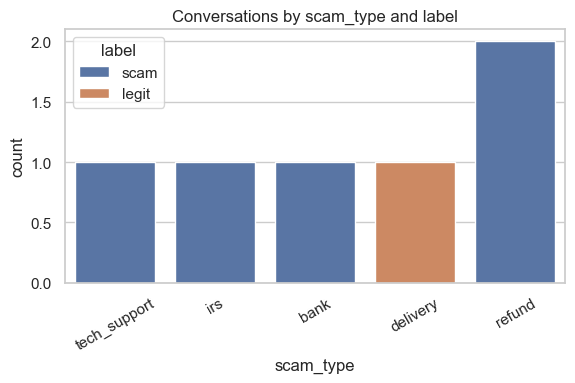

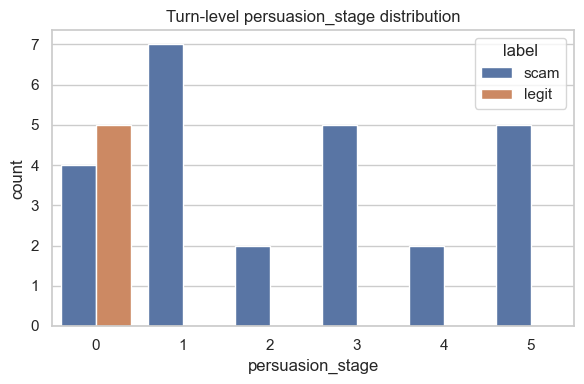

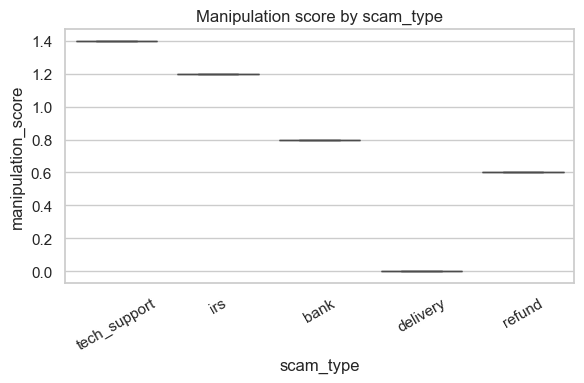

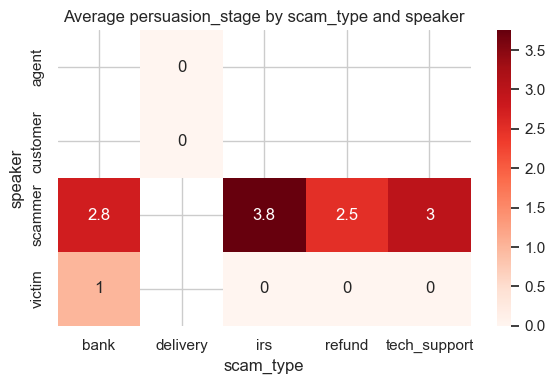

In [17]:
# Bar chart: distribution of scam_type at conversation level
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=conversation_features, x="scam_type", hue="label")
plt.title("Conversations by scam_type and label")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Histogram / bar: persuasion_stage at turn level
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=turns_df, x="persuasion_stage", hue="label")
plt.title("Turn-level persuasion_stage distribution")
plt.tight_layout()
plt.show()

# Boxplot / violin: manipulation_score by scam_type
plt.figure(figsize=(6, 4))
ax = sns.boxplot(data=conversation_features, x="scam_type", y="manipulation_score")
plt.title("Manipulation score by scam_type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Heatmap: average persuasion_stage by scam_type and speaker
heatmap_df = (
    turns_df.groupby(["scam_type", "speaker"])["persuasion_stage"]
    .mean()
    .reset_index()
    .pivot(index="speaker", columns="scam_type", values="persuasion_stage")
)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(heatmap_df, annot=True, cmap="Reds")
plt.title("Average persuasion_stage by scam_type and speaker")
plt.tight_layout()
plt.show()

## 6. Conversation-Wide Manipulation Timelines

To visualize how persuasion and manipulation evolve over time, we plot timelines for a few representative conversations showing:

- persuasion_stage vs turn_id
- aggregated urgency/authority/threat/verification vs turn_id

This highlights how scammers escalate pressure and signals across the call.

Plotting timelines for conversations: ['conv_001', 'conv_002', 'conv_003']


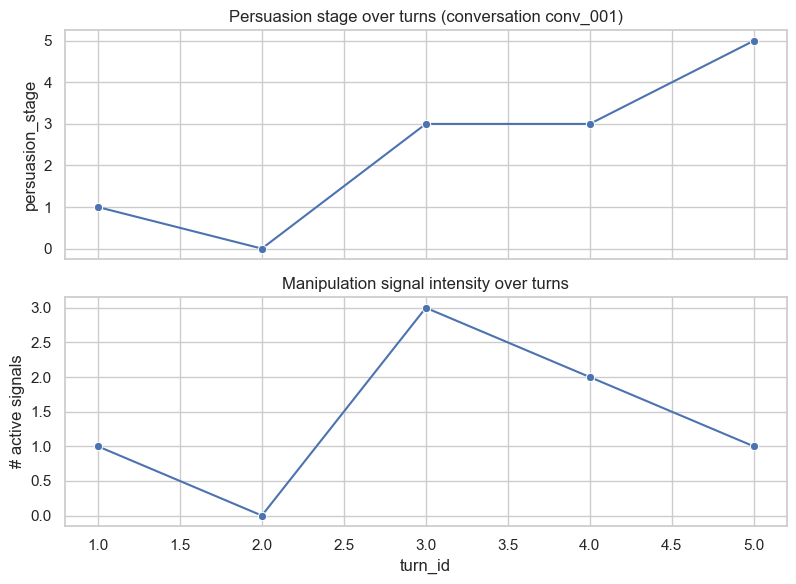

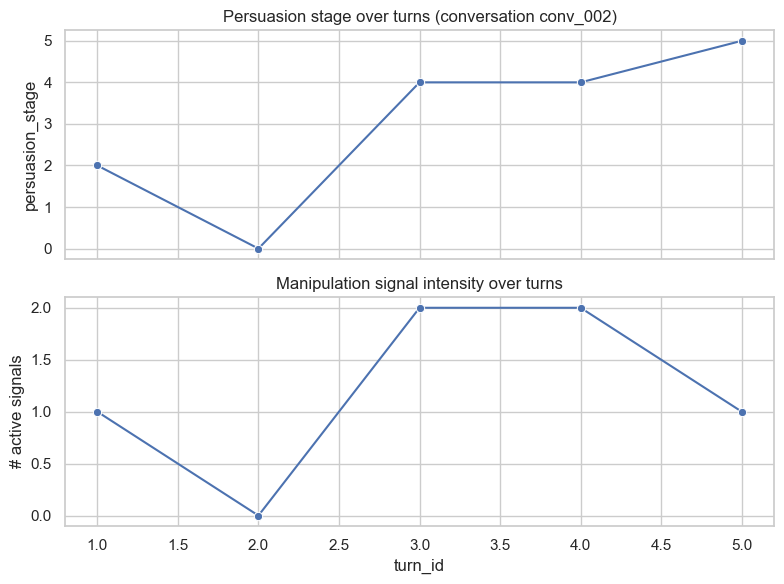

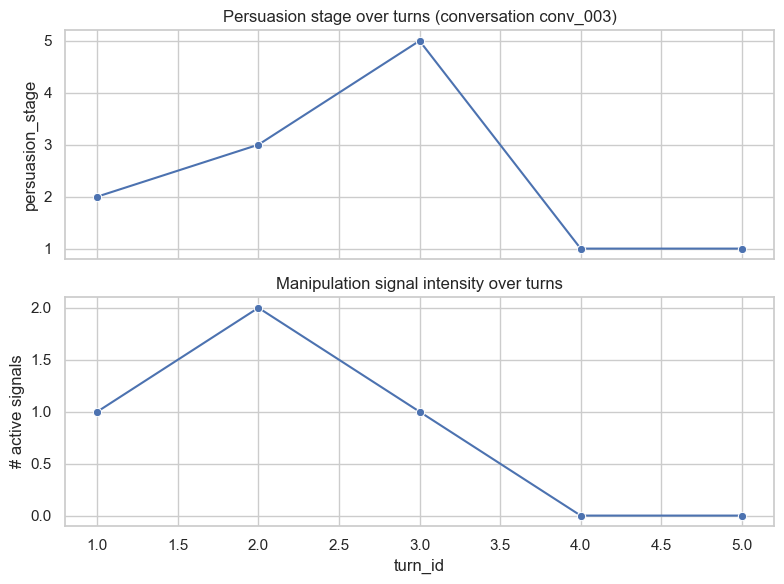

In [18]:
# Select a few representative conversations (prefer scams)
scam_convos = (
    conversation_features[conversation_features["label"] == "scam"]["conversation_id"]
    .unique()
)

sample_convos = list(scam_convos[:3]) if len(scam_convos) > 0 else list(
    conversation_features["conversation_id"].unique()[:3]
)

print("Plotting timelines for conversations:", sample_convos)

signals_for_timelines = ["urgency", "authority", "threat", "verification"]

for cid in sample_convos:
    subset = turns_df[turns_df["conversation_id"] == cid].copy()
    subset = subset.sort_values("turn_id")

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Persuasion stage timeline
    sns.lineplot(ax=axes[0], data=subset, x="turn_id", y="persuasion_stage", marker="o")
    axes[0].set_title(f"Persuasion stage over turns (conversation {cid})")
    axes[0].set_ylabel("persuasion_stage")

    # Manipulation signals timeline (sum of key signals per turn)
    subset["signal_intensity"] = subset[signals_for_timelines].sum(axis=1)
    sns.lineplot(ax=axes[1], data=subset, x="turn_id", y="signal_intensity", marker="o")
    axes[1].set_title("Manipulation signal intensity over turns")
    axes[1].set_ylabel("# active signals")
    axes[1].set_xlabel("turn_id")

    plt.tight_layout()
    plt.show()

## 7. Baseline Fraud Detection Model and Evaluation

We now build a simple baseline classifier that predicts whether a conversation is a scam based on conversation-level features:

- turn counts and persuasion statistics
- aggregated urgency/authority/threat/verification signals
- manipulation_score

We evaluate using train/test split with accuracy, precision, recall, and a confusion matrix heatmap.

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


/Users/jnkim/Desktop/coding stuff/phonefraudnlp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


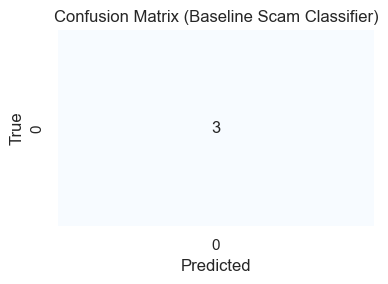

In [20]:
# Baseline classifier: scam vs legit
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Binary target: 1 if scam, 0 if legit
conversation_features["is_scam"] = conversation_features["label"].eq("scam").astype(int)

feature_cols_model = [
    "n_turns",
    "n_scammer_turns",
    "n_victim_turns",
    "max_persuasion_stage",
    "mean_persuasion_stage",
    "urgency_mean",
    "authority_mean",
    "threat_mean",
    "verification_mean",
    "manipulation_score",
]

# Drop columns that might be missing if signals are absent
feature_cols_model = [c for c in feature_cols_model if c in conversation_features.columns]

X = conversation_features[feature_cols_model]
y = conversation_features["is_scam"]

# With very small datasets, stratified splitting can fail; fall back gracefully
use_stratify = y.nunique() > 1 and y.value_counts().min() >= 2

if len(X) >= 4:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.4,
        random_state=42,
        stratify=y if use_stratify else None,
    )
else:
    # Too few conversations: train and evaluate on the same data (illustrative only)
    print("Warning: very small dataset; training and evaluating on all conversations.")
    X_train, X_test, y_train, y_test = X, X, y, y

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Baseline Scam Classifier)")
plt.tight_layout()
plt.show()

## 8. Export Trained Model Artifacts

Finally, we serialize the trained model and feature configuration to disk so it can be reused in a real-time fraud detection pipeline. We also show how to reload the model and run a quick prediction on a held-out conversation.

In [21]:
# Export trained model and feature configuration
import joblib
from pathlib import Path

ARTIFACTS_DIR = Path("generate_dataset") / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

model_path = ARTIFACTS_DIR / "baseline_scam_classifier.joblib"
config_path = ARTIFACTS_DIR / "conversation_feature_config.joblib"

joblib.dump(clf, model_path)
joblib.dump({"feature_cols": feature_cols_model}, config_path)

print("Saved model to", model_path)
print("Saved feature config to", config_path)

# Reload and run a quick prediction on a sample conversation
loaded_clf = joblib.load(model_path)
feature_cfg = joblib.load(config_path)

sample_row = conversation_features.iloc[[0]][feature_cfg["feature_cols"]]
print("Sample features:\n", sample_row)

sample_pred = loaded_clf.predict(sample_row)
print("Predicted scam flag for sample conversation:", int(sample_pred[0]))

Saved model to generate_dataset/artifacts/baseline_scam_classifier.joblib
Saved feature config to generate_dataset/artifacts/conversation_feature_config.joblib
Sample features:
    n_turns  n_scammer_turns  n_victim_turns  max_persuasion_stage  \
0        5                4               1                     5   

   mean_persuasion_stage  urgency_mean  authority_mean  threat_mean  \
0                    2.4           0.6             0.4          0.4   

   verification_mean  manipulation_score  
0                0.0                 1.4  
Predicted scam flag for sample conversation: 1


## 9. Central Overview Diagram

To wrap up, we create one central diagram that summarizes, for each scam_type:

- average maximum persuasion_stage
- average manipulation_score
- proportion of conversations that are scams
- mean urgency, authority, threat, and verification signals

This provides a single high-level view of how aggressive and manipulative each scam pattern is across the dataset.

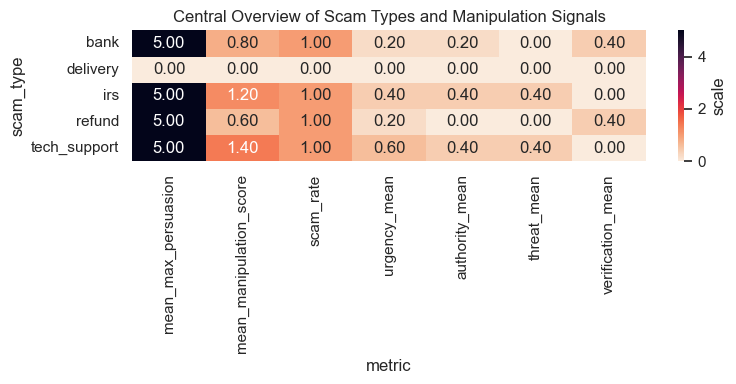

In [22]:
# Central overview heatmap by scam_type

# Aggregate key metrics per scam_type at the conversation level
summary_by_type = (
    conversation_features.groupby(["scam_type"], as_index=False).agg(
        mean_max_persuasion=("max_persuasion_stage", "mean"),
        mean_manipulation_score=("manipulation_score", "mean"),
        scam_rate=("is_scam", "mean"),  # proportion of conversations that are scams
        urgency_mean=("urgency_mean", "mean"),
        authority_mean=("authority_mean", "mean"),
        threat_mean=("threat_mean", "mean"),
        verification_mean=("verification_mean", "mean"),
    )
)

# Put metrics into a matrix for a single central heatmap
metrics_cols = [
    "mean_max_persuasion",
    "mean_manipulation_score",
    "scam_rate",
    "urgency_mean",
    "authority_mean",
    "threat_mean",
    "verification_mean",
]

heatmap_matrix = summary_by_type.set_index("scam_type")[metrics_cols]

plt.figure(figsize=(8, 4))
ax = sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    cmap="rocket_r",
    cbar_kws={"label": "scale"},
)
plt.title("Central Overview of Scam Types and Manipulation Signals")
plt.xlabel("metric")
plt.ylabel("scam_type")
plt.tight_layout()
plt.show()